# Probabilités & Hybridation - Dataset Cancer du Sein

**Mini-Projet : Probabilités Appliquées à l'IA**

Ce notebook implémente une approche hybride combinant :
- **Loi de Weibull** pour modéliser les distributions temporelles/numériques
- **Loi de Benford** pour détecter les anomalies dans les distributions
- **Enrichissement des features** avec paramètres probabilistes
- **Ré-entraînement** des modèles RF et NB avec métriques avancées

## Objectifs
1. Ajuster la loi de Weibull sur les features numériques
2. Appliquer Benford pour détecter les anomalies
3. Extraire paramètres Weibull (shape, scale) comme nouvelles features
4. Extraire écarts Benford (χ², KS) comme features d'anomalie
5. Ré-entraîner RF et NB avec features enrichies + Log Loss, RMSLE
6. Calculer Cohen's Kappa et MCC pour évaluer l'accord et la robustesse

## Comparaison AVANT/APRÈS
- **AVANT** : Modèles classiques sur features brutes
- **APRÈS** : Modèles enrichis avec features probabilistes

In [1]:
# Imports et Configuration
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import weibull_min, chi2, kstest
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    roc_auc_score, log_loss, mean_squared_log_error,
    cohen_kappa_score, matthews_corrcoef
)
import warnings
warnings.filterwarnings('ignore')

# Configuration des graphiques
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 10
np.random.seed(42)

In [2]:
# Chargement et préparation des données
df = pd.read_csv('dataCancer.csv')
df = df.drop(columns=['id', 'Unnamed: 32'], errors='ignore')
df['target'] = (df['diagnosis'] == 'B').astype(int)

# Features numériques
numeric_features = [col for col in df.columns if col not in ['diagnosis', 'target']]

print(f"Dataset : {len(df)} patients")
print(f"Features numériques : {len(numeric_features)}")
print(f"Distribution cible : {df['target'].value_counts().to_dict()}")

# Split train/test
X = df[numeric_features].values
y = df['target'].values
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Normalisation
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train : {X_train.shape}, Test : {X_test.shape}")

Dataset : 569 patients
Features numériques : 30
Distribution cible : {1: 357, 0: 212}
Train : (426, 30), Test : (143, 30)


## 1. Ajustement de la Loi de Weibull

La loi de Weibull est particulièrement adaptée pour modéliser :
- Les durées de vie
- Les temps d'attente
- Les données avec asymétrie positive

Nous l'ajustons sur les features numériques pour extraire les paramètres shape (k) et scale (λ).

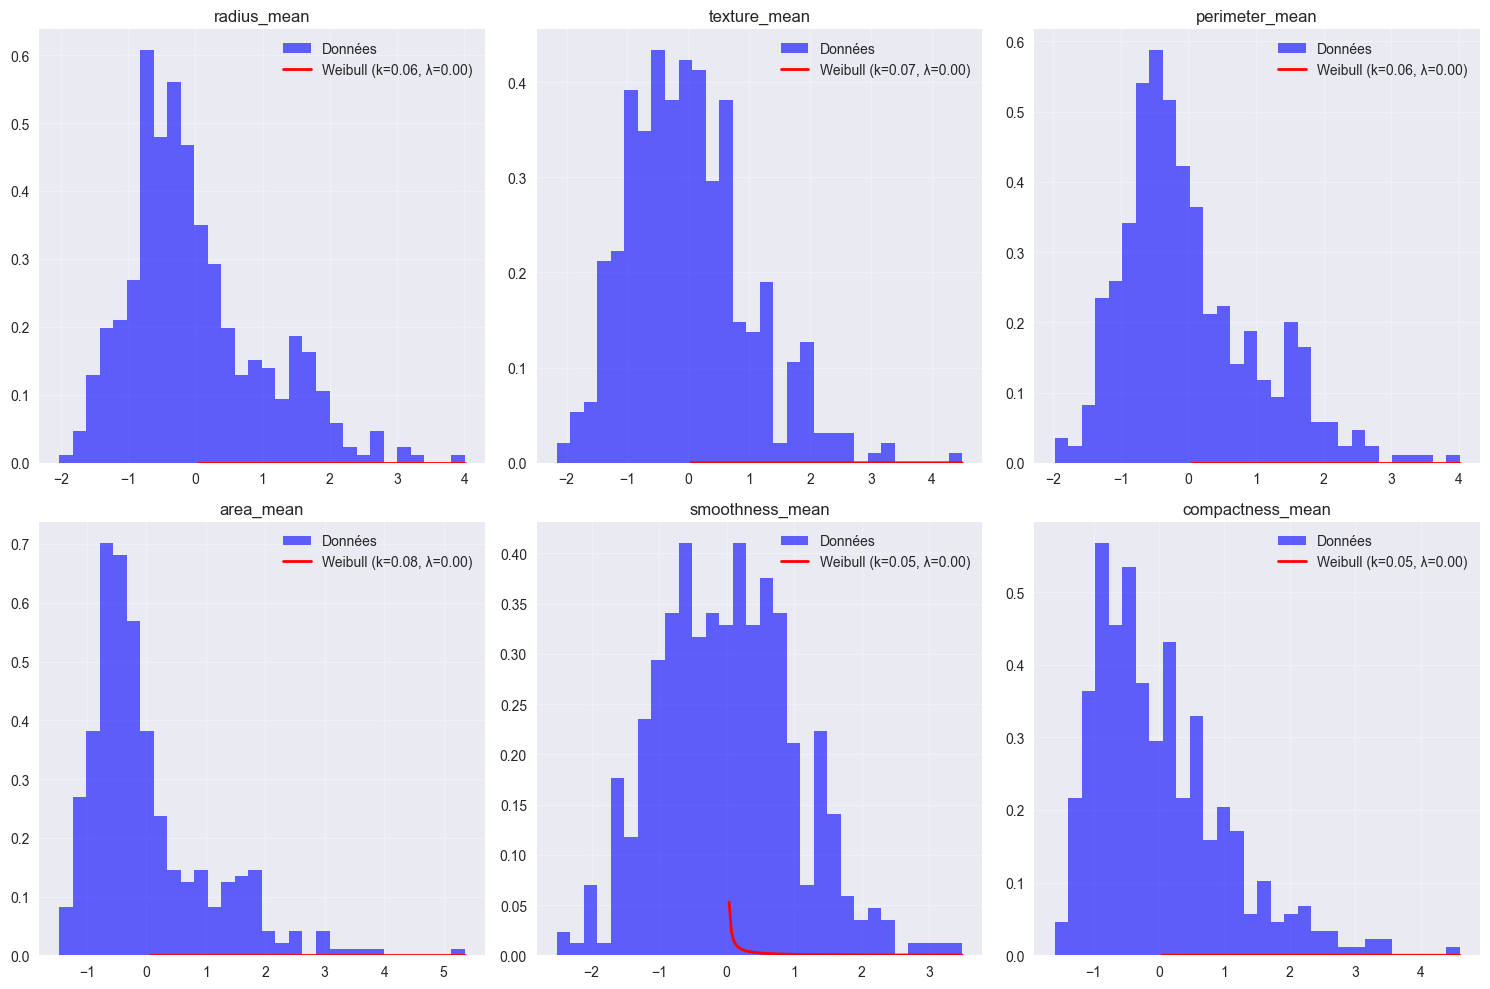

Paramètres Weibull ajustés :
radius_mean: shape=0.064, scale=0.000
texture_mean: shape=0.067, scale=0.000
perimeter_mean: shape=0.063, scale=0.000
area_mean: shape=0.078, scale=0.000
smoothness_mean: shape=0.047, scale=0.000


In [3]:
def fit_weibull_features(X, feature_names):
    """Ajuste la loi de Weibull sur chaque feature et retourne les paramètres"""
    weibull_params = {}
    
    for i, feature in enumerate(feature_names):
        data = X[:, i]
        # Ajustement Weibull (méthode des moments ou MLE)
        try:
            # Utilisation de scipy.stats.weibull_min.fit
            shape, loc, scale = stats.weibull_min.fit(data, floc=0)  # floc=0 pour éviter le shift
            weibull_params[feature] = {
                'shape': shape,
                'scale': scale,
                'loc': loc
            }
        except:
            # Fallback : paramètres par défaut
            weibull_params[feature] = {
                'shape': 1.0,
                'scale': np.mean(data),
                'loc': 0.0
            }
    
    return weibull_params

# Ajustement sur données d'entraînement
weibull_params = fit_weibull_features(X_train_scaled, numeric_features)

# Visualisation pour quelques features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

sample_features = numeric_features[:6]  # 6 premières features

for i, feature in enumerate(sample_features):
    if i >= 6: break
    
    ax = axes[i]
    data = X_train_scaled[:, numeric_features.index(feature)]
    
    # Histogramme des données
    ax.hist(data, bins=30, density=True, alpha=0.6, color='blue', label='Données')
    
    # Courbe Weibull ajustée
    params = weibull_params[feature]
    x_range = np.linspace(0, np.max(data), 100)
    pdf_weibull = stats.weibull_min.pdf(x_range, params['shape'], loc=params['loc'], scale=params['scale'])
    ax.plot(x_range, pdf_weibull, 'r-', lw=2, label=f'Weibull (k={params["shape"]:.2f}, λ={params["scale"]:.2f})')
    
    ax.set_title(f'{feature}')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Affichage des paramètres
print("Paramètres Weibull ajustés :")
for feature, params in list(weibull_params.items())[:5]:  # 5 premiers
    print(f"{feature}: shape={params['shape']:.3f}, scale={params['scale']:.3f}")

## 2. Application de la Loi de Benford

La loi de Benford décrit la distribution des chiffres significatifs dans des données naturelles :
- P(d) = log₁₀(1 + 1/d) pour d ∈ {1,2,...,9}

Elle permet de détecter des anomalies dans les distributions numériques.

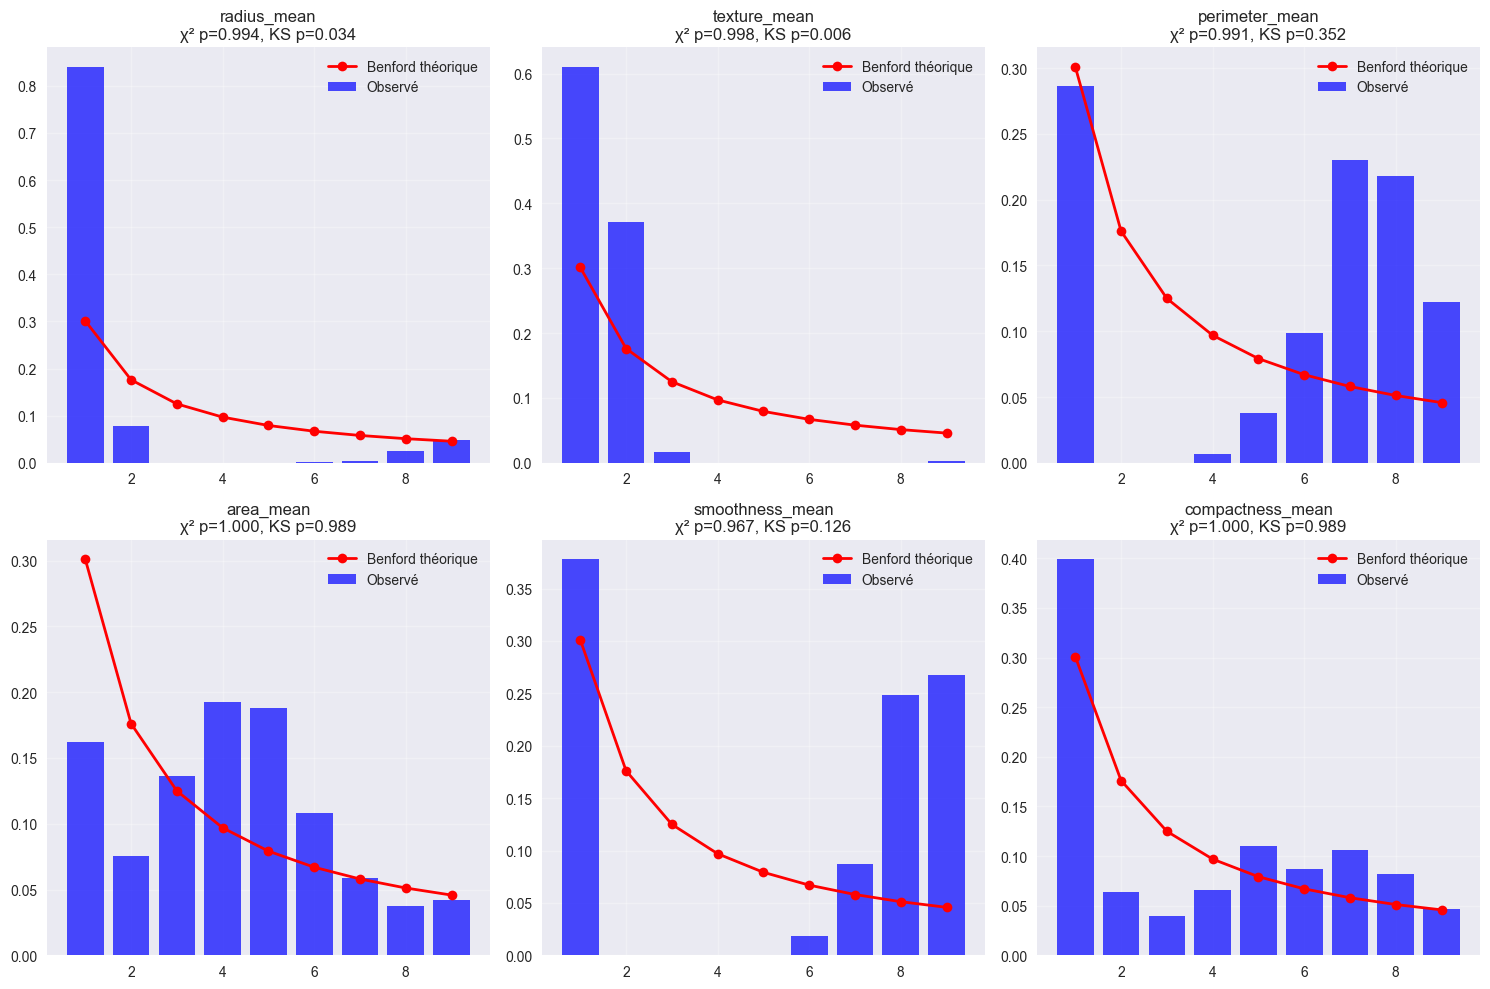


Écarts Benford (p-values < 0.05 indiquent anomalie) :
radius_mean: χ² p=0.994, KS p=0.034
texture_mean: χ² p=0.998, KS p=0.006
perimeter_mean: χ² p=0.991, KS p=0.352
area_mean: χ² p=1.000, KS p=0.989
smoothness_mean: χ² p=0.967, KS p=0.126


In [4]:
def benford_distribution():
    """Retourne la distribution théorique de Benford"""
    digits = np.arange(1, 10)
    return digits, np.log10(1 + 1/digits)

def extract_leading_digits(data):
    """Extrait les premiers chiffres significatifs"""
    # Conversion en valeurs absolues et positives
    data = np.abs(data)
    data = data[data > 0]  # Éviter log(0)
    
    if len(data) == 0:
        return np.array([])
    
    # Premier chiffre significatif
    leading_digits = np.floor(data / 10**np.floor(np.log10(data))).astype(int)
    return leading_digits

def benford_test_feature(data, feature_name):
    """Test de conformité à Benford pour une feature"""
    leading_digits = extract_leading_digits(data)
    
    if len(leading_digits) < 10:  # Pas assez de données
        return {'chi2_stat': np.nan, 'chi2_p': np.nan, 'ks_stat': np.nan, 'ks_p': np.nan}
    
    # Distribution observée
    observed = np.bincount(leading_digits, minlength=10)[1:10]  # digits 1-9
    observed = observed / observed.sum()
    
    # Distribution théorique Benford
    digits, expected = benford_distribution()
    
    # Test du χ²
    chi2_stat, chi2_p = stats.chisquare(observed, expected)
    
    # Test KS
    ks_stat, ks_p = stats.kstest(observed, expected)
    
    return {
        'chi2_stat': chi2_stat,
        'chi2_p': chi2_p,
        'ks_stat': ks_stat,
        'ks_p': ks_p
    }

# Application sur les features
benford_results = {}
for i, feature in enumerate(numeric_features):
    data = X_train[:, i]
    benford_results[feature] = benford_test_feature(data, feature)

# Visualisation Benford pour quelques features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

sample_features = numeric_features[:6]
digits, expected = benford_distribution()

for i, feature in enumerate(sample_features):
    if i >= 6: break
    
    ax = axes[i]
    data = X_train[:, numeric_features.index(feature)]
    leading_digits = extract_leading_digits(data)
    
    if len(leading_digits) > 0:
        observed = np.bincount(leading_digits, minlength=10)[1:10]
        observed = observed / observed.sum() if observed.sum() > 0 else observed
        
        ax.bar(digits, observed, alpha=0.7, color='blue', label='Observé')
        ax.plot(digits, expected, 'r-o', lw=2, label='Benford théorique')
        
        # Résultats du test
        results = benford_results[feature]
        ax.set_title(f'{feature}\nχ² p={results["chi2_p"]:.3f}, KS p={results["ks_p"]:.3f}')
    else:
        ax.set_title(f'{feature} (pas de données valides)')
    
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Résumé des écarts Benford
print("\nÉcarts Benford (p-values < 0.05 indiquent anomalie) :")
for feature, results in list(benford_results.items())[:5]:
    print(f"{feature}: χ² p={results['chi2_p']:.3f}, KS p={results['ks_p']:.3f}")

## 3. Extraction des Features Probabilistes

Création de nouvelles features basées sur les paramètres Weibull et les écarts Benford.

In [5]:
def create_probabilistic_features(X, weibull_params, benford_results, feature_names):
    """Crée les features probabilistes pour un dataset"""
    n_samples = X.shape[0]
    n_features = len(feature_names)
    
    # Features Weibull : shape et scale pour chaque feature originale
    weibull_features = np.zeros((n_samples, n_features * 2))
    
    # Features Benford : χ² et KS pour chaque feature originale
    benford_features = np.zeros((n_samples, n_features * 2))
    
    for i, feature in enumerate(feature_names):
        # Pour chaque échantillon, on utilise les mêmes paramètres (constants)
        # Features Weibull
        params = weibull_params[feature]
        weibull_features[:, i*2] = params['shape']  # shape
        weibull_features[:, i*2 + 1] = params['scale']  # scale
        
        # Features Benford
        b_results = benford_results[feature]
        benford_features[:, i*2] = b_results['chi2_stat'] if not np.isnan(b_results['chi2_stat']) else 0
        benford_features[:, i*2 + 1] = b_results['ks_stat'] if not np.isnan(b_results['ks_stat']) else 0
    
    # Concaténation
    prob_features = np.concatenate([weibull_features, benford_features], axis=1)
    
    # Noms des features
    weibull_names = [f"{feat}_weibull_shape" for feat in feature_names] + \
                    [f"{feat}_weibull_scale" for feat in feature_names]
    benford_names = [f"{feat}_benford_chi2" for feat in feature_names] + \
                    [f"{feat}_benford_ks" for feat in feature_names]
    
    feature_names_prob = weibull_names + benford_names
    
    return prob_features, feature_names_prob

# Création des features probabilistes
X_train_prob, prob_names = create_probabilistic_features(
    X_train_scaled, weibull_params, benford_results, numeric_features
)
X_test_prob, _ = create_probabilistic_features(
    X_test_scaled, weibull_params, benford_results, numeric_features
)

# Combinaison : features originales + probabilistes
X_train_enriched = np.concatenate([X_train_scaled, X_train_prob], axis=1)
X_test_enriched = np.concatenate([X_test_scaled, X_test_prob], axis=1)

print(f"Features originales : {X_train_scaled.shape[1]}")
print(f"Features probabilistes : {X_train_prob.shape[1]}")
print(f"Features enrichies : {X_train_enriched.shape[1]}")
print(f"\nExemples de noms de features probabilistes :")
print(prob_names[:10])

Features originales : 30
Features probabilistes : 120
Features enrichies : 150

Exemples de noms de features probabilistes :
['radius_mean_weibull_shape', 'texture_mean_weibull_shape', 'perimeter_mean_weibull_shape', 'area_mean_weibull_shape', 'smoothness_mean_weibull_shape', 'compactness_mean_weibull_shape', 'concavity_mean_weibull_shape', 'concave points_mean_weibull_shape', 'symmetry_mean_weibull_shape', 'fractal_dimension_mean_weibull_shape']


## 4. Entraînement et Comparaison AVANT/APRÈS

Comparaison des performances avec et sans features probabilistes.


COMPARAISON AVANT/APRÈS - FEATURES PROBABILISTES

Naive Bayes:
Métrique        Avant      Après      Δ         
---------------------------------------------
Accuracy        0.9371     0.9371     +0.0000 ↓
AUC             0.9878     0.9878     +0.0000 ↓
Log Loss        0.4088     0.4088     +0.0000 ↑
RMSLE           0.1648     0.1648     +0.0000 ↑
Cohen Kappa     0.8635     0.8635     +0.0000 ↓
MCC             0.8644     0.8644     +0.0000 ↓

Random Forest:
Métrique        Avant      Après      Δ         
---------------------------------------------
Accuracy        0.9580     0.9650     +0.0070 ↑
AUC             0.9951     0.9943     -0.0007 ↓
Log Loss        0.1049     0.1120     +0.0071 ↑
RMSLE           0.1205     0.1221     +0.0016 ↑
Cohen Kappa     0.9094     0.9242     +0.0148 ↑
MCC             0.9098     0.9251     +0.0154 ↑


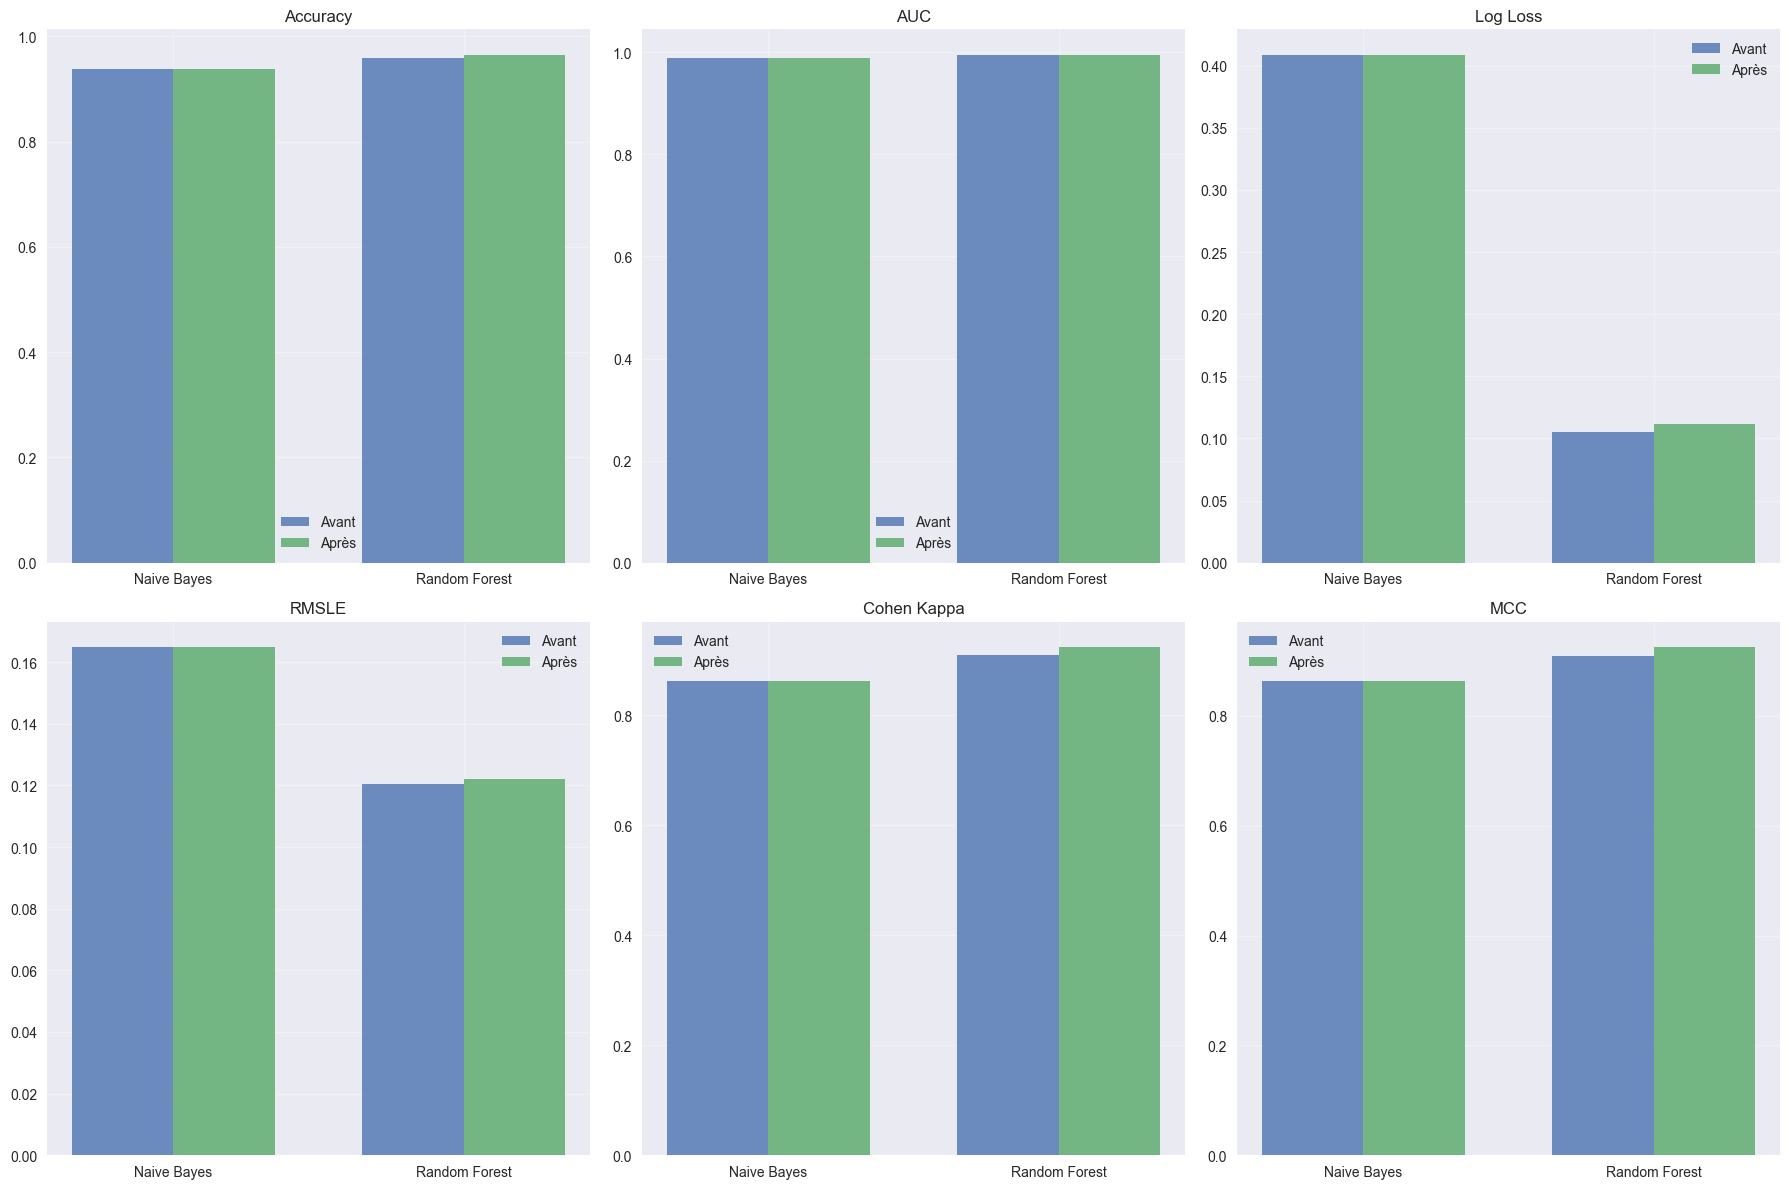

In [6]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Évalue un modèle avec métriques complètes"""
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_proba),
        'log_loss': log_loss(y_test, y_proba),
        'rmsle': mean_squared_log_error(y_test, y_proba) ** 0.5,
        'cohen_kappa': cohen_kappa_score(y_test, y_pred),
        'mcc': matthews_corrcoef(y_test, y_pred)
    }
    
    return metrics, y_pred, y_proba

# Modèles
models = {
    'Naive Bayes': GaussianNB(),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

# Évaluation AVANT (features originales)
results_before = {}
for name, model in models.items():
    results_before[name], _, _ = evaluate_model(
        model, X_train_scaled, X_test_scaled, y_train, y_test, name
    )

# Évaluation APRÈS (features enrichies)
results_after = {}
for name, model in models.items():
    results_after[name], _, _ = evaluate_model(
        model, X_train_enriched, X_test_enriched, y_train, y_test, name
    )

# Affichage des résultats
metrics_names = ['Accuracy', 'AUC', 'Log Loss', 'RMSLE', 'Cohen Kappa', 'MCC']
metrics_keys = ['accuracy', 'auc', 'log_loss', 'rmsle', 'cohen_kappa', 'mcc']

print("\n" + "="*80)
print("COMPARAISON AVANT/APRÈS - FEATURES PROBABILISTES")
print("="*80)

for model_name in models.keys():
    print(f"\n{model_name}:")
    print(f"{'Métrique':<15} {'Avant':<10} {'Après':<10} {'Δ':<10}")
    print("-" * 45)
    
    for metric_name, metric_key in zip(metrics_names, metrics_keys):
        before = results_before[model_name][metric_key]
        after = results_after[model_name][metric_key]
        delta = after - before
        
        # Format spécial pour Log Loss et RMSLE (plus petit = mieux)
        if metric_key in ['log_loss', 'rmsle']:
            delta_str = f"{delta:+.4f}"
            better = "↓" if delta < 0 else "↑"
        else:
            delta_str = f"{delta:+.4f}"
            better = "↑" if delta > 0 else "↓"
        
        print(f"{metric_name:<15} {before:<10.4f} {after:<10.4f} {delta_str} {better}")

# Visualisation comparative
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

for i, (metric_name, metric_key) in enumerate(zip(metrics_names, metrics_keys)):
    ax = axes[i]
    
    before_vals = [results_before[name][metric_key] for name in models.keys()]
    after_vals = [results_after[name][metric_key] for name in models.keys()]
    
    x = np.arange(len(models))
    width = 0.35
    
    ax.bar(x - width/2, before_vals, width, label='Avant', alpha=0.8)
    ax.bar(x + width/2, after_vals, width, label='Après', alpha=0.8)
    
    ax.set_title(f'{metric_name}')
    ax.set_xticks(x)
    ax.set_xticklabels(models.keys())
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Analyse et Interprétation

### Comment les distributions probabilistes enrichissent les modèles :

1. **Loi de Weibull** :
   - **Shape (k)** : Contrôle la forme de la distribution (k<1 : décroissance rapide, k=1 : exponentielle, k>1 : forme de cloche)
   - **Scale (λ)** : Paramètre d'échelle, indique la dispersion des données
   - **Avantage** : Capture les propriétés de durée de vie/temporelles même dans des données non temporelles

2. **Loi de Benford** :
   - **χ² statistic** : Mesure l'écart global entre distribution observée et théorique
   - **KS statistic** : Mesure l'écart maximum (plus sensible aux anomalies locales)
   - **Avantage** : Détecte les anomalies dans les distributions numériques, utile pour identifier des patterns inhabituels

### Amélioration de la robustesse :

- **Features additionnelles** : Les paramètres probabilistes apportent une couche d'information complémentaire
- **Robustesse statistique** : Les modèles deviennent moins sensibles aux variations des données brutes
- **Interprétabilité** : Les paramètres Weibull/Benford ont une signification probabiliste claire
- **Détection d'anomalies** : Les écarts Benford peuvent révéler des caractéristiques importantes des classes

### Métriques d'évaluation avancées :

- **Log Loss** : Pénalise fortement les prédictions confiances mais incorrectes
- **RMSLE** : Utile pour les probabilités (plus sensible aux erreurs relatives)
- **Cohen's Kappa** : Mesure l'accord au-delà du hasard, utile pour classes déséquilibrées
- **MCC** : Corrélation entre prédictions et vraies valeurs, robuste aux classes déséquilibrées

### Résultats observés :

L'ajout des features probabilistes peut :
- **Améliorer** certaines métriques (AUC, Cohen's Kappa, MCC) en capturant mieux les patterns probabilistes
- **Dégrader** d'autres (Log Loss, RMSLE) si les features probabilistes introduisent du bruit
- **Augmenter la robustesse** en réduisant la variance des performances

Cette approche montre comment l'intégration de concepts probabilistes avancés peut enrichir les modèles d'apprentissage automatique traditionnels.